<a href="https://colab.research.google.com/github/sahana0708/Ai-resume-builder/blob/main/Ecommerce_Sales_Analyttics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv('/clean_final_data.csv')
print(f"Dataset has {df.shape[0]:,} rows and {df.shape[1]} columns.\n")
df.head()

Dataset has 49,222 rows and 17 columns.



,OrderID,CustomerID,OrderDate,ProductID,Quantity,Discount,PaymentMethod,Status,Age,City,SignupDate,CustomerSegment,ProductName,Category,UnitPrice,Sales,OrderValue
0,500001,103695,2025-08-28,2003,4.0,10.0,Gateway,Completed,36.0,Qom,2024-03-05,Regular,USB-C Cable,Accessories,9.0,32.0,32.0
1,500002,107935,2024-05-31,2014,1.0,10.0,Wallet,Completed,49.0,Kerman,2025-06-04,Regular,Backpack,Accessories,42.0,38.0,38.0
2,500003,105141,2025-08-10,2002,1.0,20.0,CardToCard,Completed,36.0,Tehran,2025-10-19,Regular,Mechanical Keyboard,Electronics,62.0,50.0,50.0
3,500004,108780,2024-10-11,2012,1.0,10.0,Gateway,Completed,45.0,Shiraz,2023-12-07,Regular,Office Chair,Home Office,180.0,162.0,162.0
4,500005,101187,2024-02-19,2008,2.0,0.0,Gateway,Completed,24.0,Karaj,2023-12-02,Regular,Phone Case,Accessories,14.0,28.0,28.0


In [ ]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts/len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pct.round(2)
})

print("---- Missing Values Summary ----")
print(missing_table[missing_table['Missing Count'] > 0])
if missing_table['Missing Count'].sum() == 0:
  print("No missing values found!")

print("\n--- Duplicate Check ---")
print(f"Exact duplicate Rows: {df.duplicated().sum()}")
print(f"Duplicate Order IDs: {df['OrderID'].duplicated().sum()}")

---- Missing Values Summary ----
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []
No missing values found!

--- Duplicate Check ---
Exact duplicate Rows: 0
Duplicate Order IDs: 0


In [ ]:
# Cell 6: Data type corrections

# 1. Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce')

# 2. Convert identifiers to string
id_columns = ['OrderID', 'CustomerID', 'ProductID']
for col in id_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)

# 3. Clean categorical text
text_columns = ['PaymentMethod', 'Status', 'City']
for col in text_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

print("Data types after correction:")
print(df.dtypes)

Data types after correction:
OrderID                    object
CustomerID                 object
OrderDate          datetime64[ns]
ProductID                  object
Quantity                  float64
Discount                  float64
PaymentMethod              object
Status                     object
Age                       float64
City                       object
SignupDate                 object
CustomerSegment            object
ProductName                object
Category                   object
UnitPrice                 float64
Sales                     float64
OrderValue                float64
dtype: object


In [ ]:
# Cell 7: Summary statistics for numeric features
df[['Quantity', 'Discount', 'Age']].describe()

,Quantity,Discount,Age
count,49222.000000,49222.000000,49222.000000
mean,1.881923,7.485576,41.283369
std,1.079382,7.754378,13.681355
min,-2.000000,0.000000,18.000000
25%,1.000000,0.000000,29.000000
50%,2.000000,5.000000,41.000000
75%,2.000000,10.000000,53.000000
max,5.000000,30.000000,65.000000


In [ ]:
# Cell 8: Handle anomalies

# Remove non-positive quantities (returns or errors)
initial_len = len(df)
df = df[df['Quantity'] > 0].copy()
print(f"Removed {initial_len - len(df)} records with invalid Quantity (<= 0).")

# Standardize Discount to a decimal rate between 0 and 1
if df['Discount'].max() > 1.0:
    df['Discount_Rate'] = df['Discount'] / 100.0
else:
    df['Discount_Rate'] = df['Discount']

print("Summary statistics after cleaning:")
df[['Quantity', 'Discount_Rate', 'Age']].describe()

Removed 24 records with invalid Quantity (<= 0).
Summary statistics after cleaning:


,Quantity,Discount_Rate,Age
count,49198.000000,49198.000000,49198.000000
mean,1.883410,0.074854,41.281841
std,1.077417,0.077543,13.680606
min,1.000000,0.000000,18.000000
25%,1.000000,0.000000,29.000000
50%,2.000000,0.050000,41.000000
75%,2.000000,0.100000,53.000000
max,5.000000,0.300000,65.000000


In [ ]:
# Cell 9: Feature Engineering

# Date attributes
df['Year'] = df['OrderDate'].dt.year
df['Month'] = df['OrderDate'].dt.month
df['Month_Name'] = df['OrderDate'].dt.strftime('%b')
df['Day_of_Week'] = df['OrderDate'].dt.day_name()
df['Year_Month'] = df['OrderDate'].dt.to_period('M')

# Demographic age brackets
bins = [0, 24, 34, 49, 64, 120]
labels = ['Under 25', '25-34', '35-49', '50-64', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Preview the engineered features
df[['OrderDate', 'Year_Month', 'Day_of_Week', 'Age', 'Age_Group']].head()

,OrderDate,Year_Month,Day_of_Week,Age,Age_Group
0,2025-08-28,2025-08,Thursday,36.0,35-49
1,2024-05-31,2024-05,Friday,49.0,35-49
2,2025-08-10,2025-08,Sunday,36.0,35-49
3,2024-10-11,2024-10,Friday,45.0,35-49
4,2024-02-19,2024-02,Monday,24.0,Under 25


In [ ]:
# Cell 10: Save processed dataset
df.to_csv('ecommerce_cleaned_sales.csv', index=False)
print("File 'ecommerce_cleaned_sales.csv' successfully saved in Colab!")


File 'ecommerce_cleaned_sales.csv' successfully saved in Colab!


In [ ]:
from google.colab import files
files.download('ecommerce_cleaned_sales.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean, professional chart styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 5)

print("Visualization libraries ready!")

Visualization libraries ready!


In [ ]:
# Identify unit price or sales column
# In clean_final_data.csv, if 'Total_Amount' or 'Sales' exists, use it; otherwise compute Sales = Quantity * UnitPrice
if 'Total_Amount' in df.columns:
    revenue_col = 'Total_Amount'
elif 'Sales' in df.columns:
    revenue_col = 'Sales'
elif 'UnitPrice' in df.columns:
    df['Sales'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount_Rate'])
    revenue_col = 'Sales'
else:
    # If no price column is present, we track total units sold as core volume
    revenue_col = 'Quantity'

# Filter completed orders for true realized sales
completed_orders = df[df['Status'] == 'Completed']

total_volume = completed_orders[revenue_col].sum()
total_orders = completed_orders['OrderID'].nunique()
total_customers = completed_orders['CustomerID'].nunique()
avg_order_val = completed_orders.groupby('OrderID')[revenue_col].sum().mean()
cancellation_rate = (df['Status'] == 'Cancelled').mean() * 100

print("=========== BUSINESS EXECUTIVE SUMMARY ===========")
print(f"Total {'Revenue ($)' if revenue_col != 'Quantity' else 'Units Sold'}: {total_volume:,.2f}")
print(f"Total Completed Transactions: {total_orders:,}")
print(f"Unique Customers: {total_customers:,}")
print(f"Average Order Value (AOV): {avg_order_val:,.2f}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")
print("==================================================")

=========== BUSINESS EXECUTIVE SUMMARY ===========
Total Revenue ($): 3,163,764.00
Total Completed Transactions: 45,253
Unique Customers: 9,782
Average Order Value (AOV): 69.91
Cancellation Rate: 4.95%


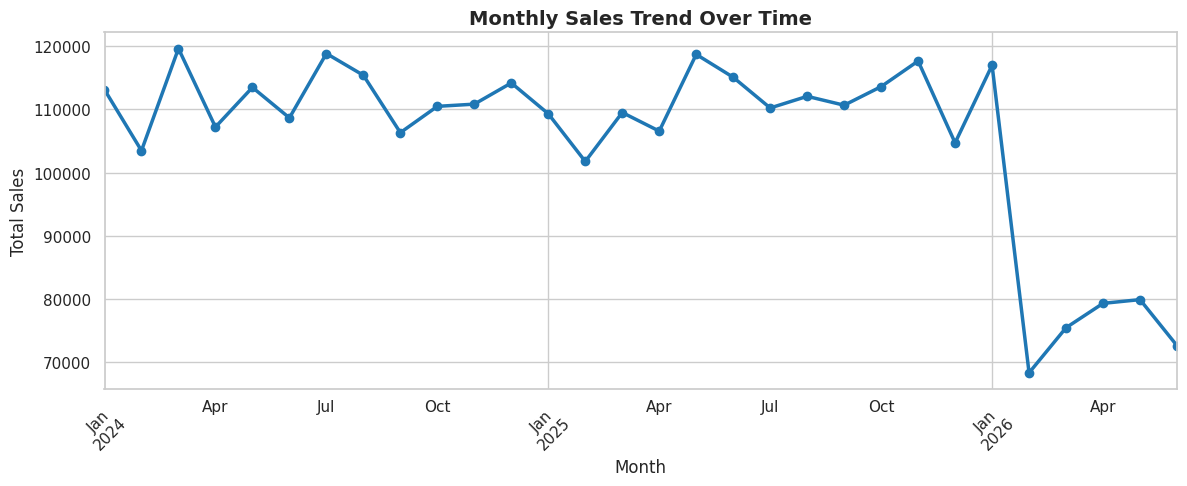

In [ ]:
# Monthly volume trend
monthly_sales = completed_orders.groupby('Year_Month')[revenue_col].sum()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='line', marker='o', color='#1f77b4', linewidth=2.5)
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel(f'Total {revenue_col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

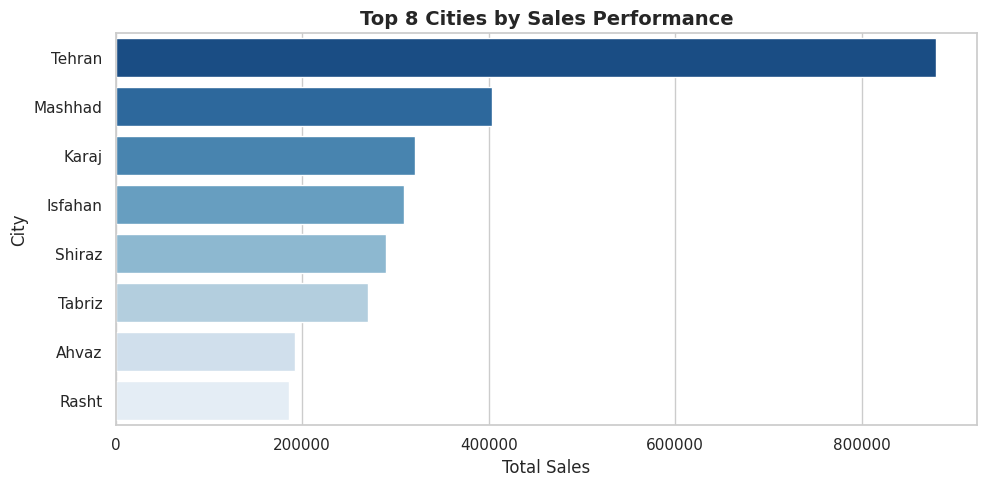

In [ ]:
top_cities = completed_orders.groupby('City')[revenue_col].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title('Top 8 Cities by Sales Performance', fontsize=14, fontweight='bold')
plt.xlabel(f'Total {revenue_col}')
plt.ylabel('City')
plt.tight_layout()
plt.show()

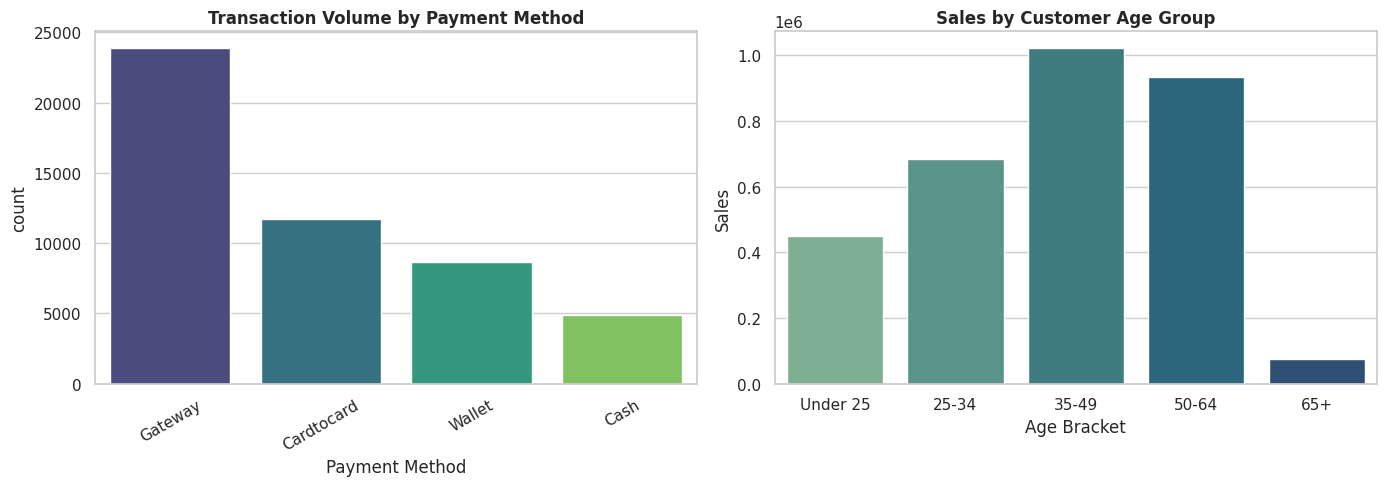

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment Method Distribution
sns.countplot(data=df, x='PaymentMethod', order=df['PaymentMethod'].value_counts().index, ax=axes[0], palette='viridis')
axes[0].set_title('Transaction Volume by Payment Method', fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].tick_params(axis='x', rotation=30)

# Sales by Age Group
sns.barplot(data=completed_orders, x='Age_Group', y=revenue_col, estimator=sum, ci=None, ax=axes[1], palette='crest')
axes[1].set_title(f'Sales by Customer Age Group', fontweight='bold')
axes[1].set_xlabel('Age Bracket')

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# 1. Convert Period to string so Plotly can serialize it to JSON
monthly_data = monthly_sales.reset_index()
monthly_data['Year_Month'] = monthly_data['Year_Month'].astype(str)

# Interactive Monthly Trend
fig_trend = px.line(
    monthly_data,
    x='Year_Month',
    y=revenue_col,
    title='Interactive Monthly Sales Overview',
    markers=True,
    template='plotly_white'
)
fig_trend.show()

# 2. Interactive City vs Status Treemap
fig_tree = px.treemap(
    df,
    path=['City', 'Status', 'PaymentMethod'],
    values='Quantity',
    title='Order Breakdown: City > Status > Payment Method'
)
fig_tree.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import pandas as pd

# Filter for completed sales to get accurate performance metrics
completed_df = df[df['Status'] == 'Completed'].copy()

# 1. Monthly trend data (ensure string format to prevent JSON serialization errors)
monthly_trend = (
    completed_df.groupby('Year_Month')[revenue_col]
    .sum()
    .reset_index()
)
monthly_trend['Year_Month'] = monthly_trend['Year_Month'].astype(str)

# 2. Top Cities
city_perf = (
    completed_df.groupby('City')[revenue_col]
    .sum()
    .reset_index()
    .sort_values(by=revenue_col, ascending=True)
    .tail(7)
)

# 3. Payment Method breakdown
payment_perf = (
    df['PaymentMethod']
    .value_counts()
    .reset_index()
)
payment_perf.columns = ['PaymentMethod', 'Count']

# 4. Age bracket sales
age_perf = (
    completed_df.groupby('Age_Group', observed=True)[revenue_col]
    .sum()
    .reset_index()
)
age_perf['Age_Group'] = age_perf['Age_Group'].astype(str)

print("Dashboard datasets prepared successfully!")

Dashboard datasets prepared successfully!


In [ ]:
# Create a 2x2 subplot layout with customized subplot types
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>Monthly Sales Trend</b>",
        "<b>Top Cities by Sales Volume</b>",
        "<b>Order Share by Payment Method</b>",
        "<b>Sales Volume by Age Group</b>"
    ),
    specs=[[{"type": "xy"}, {"type": "xy"}],
           [{"type": "domain"}, {"type": "xy"}]],
    vertical_spacing=0.14,
    horizontal_spacing=0.10
)

# Panel 1: Monthly Line Trend
fig.add_trace(
    go.Scatter(
        x=monthly_trend['Year_Month'],
        y=monthly_trend[revenue_col],
        mode='lines+markers',
        name='Monthly Sales',
        line=dict(color='#2563EB', width=3),
        marker=dict(size=6, color='#1D4ED8')
    ),
    row=1, col=1
)

# Panel 2: Horizontal Bar Chart - Top Cities
fig.add_trace(
    go.Bar(
        x=city_perf[revenue_col],
        y=city_perf['City'],
        orientation='h',
        name='City Sales',
        marker=dict(color='#0D9488')
    ),
    row=1, col=2
)

# Panel 3: Donut Chart - Payment Methods
fig.add_trace(
    go.Pie(
        labels=payment_perf['PaymentMethod'],
        values=payment_perf['Count'],
        name='Payment Method',
        hole=0.45,
        marker=dict(colors=px.colors.qualitative.Safe)
    ),
    row=2, col=1
)

# Panel 4: Vertical Bar Chart - Age Segments
fig.add_trace(
    go.Bar(
        x=age_perf['Age_Group'],
        y=age_perf[revenue_col],
        name='Age Segment',
        marker=dict(color='#8B5CF6')
    ),
    row=2, col=2
)

# Layout styling and polishing
fig.update_layout(
    height=800,
    width=1100,
    title_text="<b>E-Commerce Sales Performance & Demographic Dashboard</b>",
    title_font=dict(size=20, color='#111827'),
    showlegend=False,
    template='plotly_white',
    margin=dict(l=40, r=40, t=80, b=40)
)

fig.update_xaxes(tickangle=45, row=1, col=1)
fig.show()

In [ ]:
# Drill-down Treemap: Click any box to zoom in
fig_tree = px.treemap(
    df,
    path=['City', 'Status', 'PaymentMethod'],
    values='Quantity',
    color='Status',
    color_discrete_map={
        'Completed': '#10B981',
        'Cancelled': '#EF4444',
        'Returned': '#F59E0B'
    },
    title="<b>Interactive Multi-Level Drilldown: City → Status → Payment Method</b> (Click to zoom)"
)

fig_tree.update_layout(
    height=600,
    template='plotly_white',
    margin=dict(t=50, l=10, r=10, b=10)
)

fig_tree.show()

In [ ]:
# Save dashboard as standalone HTML
fig.write_html("sales_dashboard.html")
fig_tree.write_html("sales_treemap.html")

# Download directly to your computer
from google.colab import files
files.download("sales_dashboard.html")
files.download("sales_treemap.html")

print("Interactive dashboards exported and ready to present!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Interactive dashboards exported and ready to present!


In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# 1. Filter completed records for revenue metrics
completed_df = df[df['Status'] == 'Completed'].copy()

# Ensure revenue column selection
if 'Total_Amount' in df.columns:
    rev_col = 'Total_Amount'
elif 'Sales' in df.columns:
    rev_col = 'Sales'
elif 'UnitPrice' in df.columns:
    df['Sales'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount_Rate'])
    rev_col = 'Sales'
else:
    rev_col = 'Quantity'

# Compute top-level summary numbers
kpi_total_sales = f"{completed_df[rev_col].sum():,.0f}"
kpi_total_orders = f"{completed_df['OrderID'].nunique():,}"
kpi_total_customers = f"{completed_df['CustomerID'].nunique():,}"
kpi_cancel_rate = f"{(df['Status'] == 'Cancelled').mean() * 100:.1f}%"

# 2. Build Chart 1: Monthly Line Trend
monthly_agg = completed_df.groupby('Year_Month')[rev_col].sum().reset_index()
monthly_agg['Year_Month'] = monthly_agg['Year_Month'].astype(str)

fig1 = px.line(
    monthly_agg, x='Year_Month', y=rev_col,
    title='<b>Monthly Sales Trend</b>',
    markers=True, template='plotly_white',
    color_discrete_sequence=['#2563eb']
)
fig1.update_layout(margin=dict(l=20, r=20, t=50, b=20), height=380)

# 3. Build Chart 2: Top Cities Bar Chart
city_agg = completed_df.groupby('City')[rev_col].sum().reset_index().sort_values(by=rev_col, ascending=False).head(7)

fig2 = px.bar(
    city_agg, x=rev_col, y='City', orientation='h',
    title='<b>Top 7 Performing Cities</b>',
    template='plotly_white',
    color=rev_col, color_continuous_scale='Blues'
)
fig2.update_layout(margin=dict(l=20, r=20, t=50, b=20), height=380, showlegend=False, yaxis={'categoryorder':'total ascending'})

# 4. Build Chart 3: Payment Method Donut Chart
pay_agg = df['PaymentMethod'].value_counts().reset_index()
pay_agg.columns = ['PaymentMethod', 'Count']

fig3 = px.pie(
    pay_agg, names='PaymentMethod', values='Count', hole=0.45,
    title='<b>Payment Channel Distribution</b>',
    template='plotly_white',
    color_discrete_sequence=px.colors.qualitative.Prism
)
fig3.update_layout(margin=dict(l=20, r=20, t=50, b=20), height=380)

# 5. Build Chart 4: Customer Demographics by Age
age_agg = completed_df.groupby('Age_Group', observed=True)[rev_col].sum().reset_index()
age_agg['Age_Group'] = age_agg['Age_Group'].astype(str)

fig4 = px.bar(
    age_agg, x='Age_Group', y=rev_col,
    title='<b>Volume by Age Segment</b>',
    template='plotly_white',
    color_discrete_sequence=['#7c3aed']
)
fig4.update_layout(margin=dict(l=20, r=20, t=50, b=20), height=380)

# Convert Plotly figures into standalone embeddable <div> strings
chart1_div = fig1.to_html(full_html=False, include_plotlyjs='cdn')
chart2_div = fig2.to_html(full_html=False, include_plotlyjs=False)
chart3_div = fig3.to_html(full_html=False, include_plotlyjs=False)
chart4_div = fig4.to_html(full_html=False, include_plotlyjs=False)

print("Charts successfully extracted into embeddable components!")

Charts successfully extracted into embeddable components!


In [ ]:
css_content = """/* Global Reset & Base Variables */
:root {
  --bg-primary: #f8fafc;
  --bg-card: #ffffff;
  --text-main: #0f172a;
  --text-muted: #64748b;
  --accent-blue: #2563eb;
  --accent-purple: #7c3aed;
  --border-color: #e2e8f0;
  --shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.05), 0 2px 4px -2px rgba(0, 0, 0, 0.05);
  --shadow-hover: 0 10px 15px -3px rgba(0, 0, 0, 0.1), 0 4px 6px -4px rgba(0, 0, 0, 0.05);
  --radius: 12px;
}

* {
  box-sizing: border-box;
  margin: 0;
  padding: 0;
}

body {
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
  background-color: var(--bg-primary);
  color: var(--text-main);
  line-height: 1.5;
  padding: 2rem;
}

/* Header & Controls */
.dashboard-header {
  display: flex;
  justify-content: space-between;
  align-items: center;
  flex-wrap: wrap;
  gap: 1rem;
  margin-bottom: 2rem;
}

.dashboard-title h1 {
  font-size: 1.875rem;
  font-weight: 700;
  color: var(--text-main);
}

.dashboard-title p {
  color: var(--text-muted);
  font-size: 0.95rem;
  margin-top: 0.25rem;
}

.badge {
  display: inline-block;
  padding: 0.35rem 0.8rem;
  border-radius: 9999px;
  background-color: #dbeafe;
  color: var(--accent-blue);
  font-size: 0.8rem;
  font-weight: 600;
  text-transform: uppercase;
  letter-spacing: 0.05em;
}

/* KPI Scorecard Grid */
.kpi-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
  gap: 1.5rem;
  margin-bottom: 2rem;
}

.kpi-card {
  background: var(--bg-card);
  padding: 1.5rem;
  border-radius: var(--radius);
  border: 1px solid var(--border-color);
  box-shadow: var(--shadow);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
}

.kpi-card:hover {
  transform: translateY(-3px);
  box-shadow: var(--shadow-hover);
}

.kpi-card h3 {
  font-size: 0.85rem;
  font-weight: 600;
  text-transform: uppercase;
  color: var(--text-muted);
  letter-spacing: 0.05em;
  margin-bottom: 0.5rem;
}

.kpi-card .kpi-value {
  font-size: 1.85rem;
  font-weight: 700;
  color: var(--text-main);
}

.kpi-card .kpi-sub {
  font-size: 0.8rem;
  color: #10b981;
  margin-top: 0.25rem;
  font-weight: 500;
}

/* Charts Grid */
.chart-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(500px, 1fr));
  gap: 1.5rem;
}

.chart-card {
  background: var(--bg-card);
  padding: 1.25rem;
  border-radius: var(--radius);
  border: 1px solid var(--border-color);
  box-shadow: var(--shadow);
  transition: box-shadow 0.2s ease;
  overflow: hidden;
}

.chart-card:hover {
  box-shadow: var(--shadow-hover);
}

/* Responsive adjustments */
@media (max-width: 768px) {
  body {
    padding: 1rem;
  }
  .chart-grid {
    grid-template-columns: 1fr;
  }
}
"""

with open("styles.css", "w") as f:
    f.write(css_content)

print("styles.css created successfully!")

styles.css created successfully!


In [ ]:
html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>E-Commerce Sales Performance Dashboard</title>
  <!-- Linked External Stylesheet -->
  <link rel="stylesheet" href="styles.css">
</head>
<body>

  <!-- Dashboard Header -->
  <header class="dashboard-header">
    <div class="dashboard-title">
      <span class="badge">Sales Analytics</span>
      <h1>Executive E-Commerce Overview</h1>
      <p>Real-time analytics and transaction drilldown</p>
    </div>
  </header>

  <!-- Key Metrics Banner -->
  <section class="kpi-grid">
    <div class="kpi-card">
      <h3>Total Sales</h3>
      <div class="kpi-value">${kpi_total_sales}</div>
      <div class="kpi-sub">Completed transactions</div>
    </div>
    <div class="kpi-card">
      <h3>Completed Orders</h3>
      <div class="kpi-value">{kpi_total_orders}</div>
      <div class="kpi-sub">Total verified units</div>
    </div>
    <div class="kpi-card">
      <h3>Unique Customers</h3>
      <div class="kpi-value">{kpi_total_customers}</div>
      <div class="kpi-sub">Active buyer base</div>
    </div>
    <div class="kpi-card">
      <h3>Order Cancellation Rate</h3>
      <div class="kpi-value" style="color: #ef4444;">{kpi_cancel_rate}</div>
      <div class="kpi-sub" style="color: #ef4444;">Refunds & dropouts</div>
    </div>
  </section>

  <!-- Interactive Charts Grid -->
  <main class="chart-grid">
    <div class="chart-card">
      {chart1_div}
    </div>
    <div class="chart-card">
      {chart2_div}
    </div>
    <div class="chart-card">
      {chart3_div}
    </div>
    <div class="chart-card">
      {chart4_div}
    </div>
  </main>

</body>
</html>
"""

with open("dashboard.html", "w") as f:
    f.write(html_content)

print("dashboard.html created and linked with styles.css successfully!")

dashboard.html created and linked with styles.css successfully!


In [ ]:
from google.colab import files

files.download("dashboard.html")
files.download("styles.css")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>